In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

#  Generate numerical data

In [2]:
np.random.seed(42)

X = np.arange(1, 101)
y = 3 * X + 5

#  Split data into training and testing data

In [3]:
X_train = X[:80]
y_train = y[:80]

X_test = X[80:]
y_test = y[80:]

# Build the model

In [4]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model

In [5]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train the model

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.1,
    verbose=0
)

# Evaluate the model

In [13]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

Test Loss: 0.10486481338739395
Test MAE: 0.280221551656723


# Predict unseen test inputs

In [14]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


# Display actual vs predicted values

In [21]:
print("\nActual vs Predicted:")

for i in range(len(X_test)):
    print(
        "Input:", X_test[i],
        "Actual:", y_test[i],
        "Predicted:", round((predictions[i][0]),)
    )


Actual vs Predicted:
Input: 81 Actual: 248 Predicted: 248
Input: 82 Actual: 251 Predicted: 251
Input: 83 Actual: 254 Predicted: 254
Input: 84 Actual: 257 Predicted: 257
Input: 85 Actual: 260 Predicted: 260
Input: 86 Actual: 263 Predicted: 263
Input: 87 Actual: 266 Predicted: 266
Input: 88 Actual: 269 Predicted: 269
Input: 89 Actual: 272 Predicted: 272
Input: 90 Actual: 275 Predicted: 275
Input: 91 Actual: 278 Predicted: 278
Input: 92 Actual: 281 Predicted: 281
Input: 93 Actual: 284 Predicted: 284
Input: 94 Actual: 287 Predicted: 287
Input: 95 Actual: 290 Predicted: 290
Input: 96 Actual: 293 Predicted: 293
Input: 97 Actual: 296 Predicted: 296
Input: 98 Actual: 299 Predicted: 299
Input: 99 Actual: 302 Predicted: 303
Input: 100 Actual: 305 Predicted: 306


# Actual vs Predicted graph

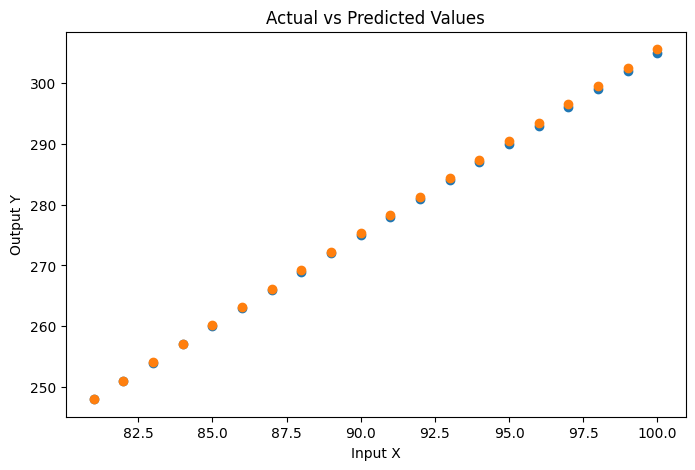

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label='Actual')
plt.scatter(X_test, predictions, label='Predicted')

plt.xlabel("Input X")
plt.ylabel("Output Y")
plt.title("Actual vs Predicted Values")
plt.show()

# Loss curve

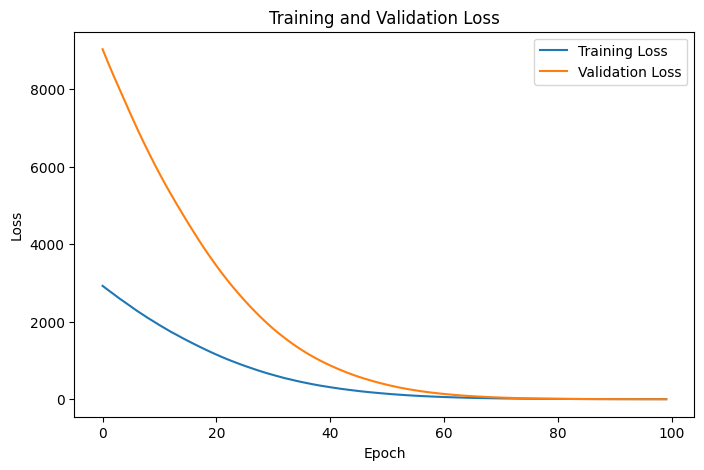

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()